Задание 1 (8 баллов)
Обучите модель с минимум 15 слоями, где у каждого слоя разные параметры (Dropout, Conv1d и Pooling, Linear считаются слоями, остальное нет, но их тоже можно использовать). Как минимум 4 слоя должны быть наложены друг на друга и как минимум 2 параллельных слоя (последовательности слоев). Должен быть хотя бы один слой каждого типа.

Вместо графиков f1 меры сделайте графики для точности и полноты. Пообучайте модель подольше, чтобы посмотреть на то как изменяются метрики.

Напишите короткую функцию для предсказания класса отдельного текста. Возьмите любой новый новостной текст и предскажите его класс. Правильное ли предсказание?

Советы: Начните с небольших сетей и постепенно добавляйте слои и увеличивайте параметры, не пытайтесь сразу собрать все слои. Иногда кернел может крашиться просто так или из-за слишком больших матриц. Помимо уменьшения параметров, вы можете попробовать уменьшить batch size.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data

In [2]:
import pandas as pd
import numpy as np
from string import punctuation
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/lenta_40k.csv')

In [5]:
data.dropna(subset=['topic', 'text'], inplace=True)

In [6]:
data

,text,topic
0,Россия должна сотрудничать с Всемирным антидоп...,Спорт
1,Уголовный суд Кувейта 28 июня освободил под за...,Мир
2,Французский журнал Charlie Hebdo опубликовал н...,Интернет и СМИ
3,В Петербурге в доме № 53 по улице Лени Голиков...,Россия
4,"В московском аэропорту ""Домодедово"" задержан г...",Россия
...,...,...
44351,Российский Минфин может пересмотреть минимальн...,Экономика
44352,Сотрудники Службы безопасности Украины (СБУ) с...,Бывший СССР
44353,Америке следует задуматься над поставками на У...,Силовые структуры
44354,"Опознаны тела 71 человека, погибшего в результ...",Мир


In [7]:
def preprocess(text):
    tokens = text.lower().split()
    tokens = [token.strip(punctuation) for token in tokens]
    return tokens

In [8]:
# словарь
vocab = Counter()

for text in data.text:
    vocab.update(preprocess(text))

In [9]:
len(vocab)

354611

In [10]:
# отфильтрованный словарь
filtered_vocab = set()

for word in vocab:
    if vocab[word] > 30:
        filtered_vocab.add(word)

In [11]:
len(filtered_vocab)

24091

In [12]:
# индексируем слова
word2id = {'PAD':0}

for word in filtered_vocab:
    word2id[word] = len(word2id)

In [13]:
id2word = {i:word for word, i in word2id.items()}

Обертка для данных - такая же как и в предыдущем семинаре

In [14]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, word2id, MAX_LEN, texts, targets):
        self.texts = [torch.LongTensor([word2id.get(w, 0) for w in self.preprocess(t)][:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True)
        self.word2id = word2id
        self.MAX_LEN = MAX_LEN
        self.length = len(texts)
        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        return self.texts[index], self.target[index]

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens if token.strip(punctuation)]
        return tokens

In [15]:
MAX_LEN = 200

In [16]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.topic))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.topic]

In [17]:
print(f"Количество классов: {len(label2id)}")
print("Примеры классов:", list(id2label.values())[:5])

Количество классов: 19
Примеры классов: ['Бизнес', 'Библиотека', 'Россия', 'Дом', 'Легпром']


In [18]:
train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.05)

In [19]:
training_set = Dataset(word2id, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=256, shuffle=True, )

In [20]:
valid_set = Dataset(word2id, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=256, shuffle=True)

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
!pip install tqdm

In [29]:
from tqdm.auto import tqdm

In [25]:
from sklearn.metrics import precision_score, recall_score

In [21]:
def train(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = []
    epoch_precision = []
    epoch_recall = []

    pbar = tqdm(iterator, desc="Training", leave=False)

    for texts, ys in pbar:
        optimizer.zero_grad()
        predictions = model(texts.to(device)).squeeze()
        loss = criterion(predictions, ys.to(device))

        loss.backward()
        optimizer.step()

        preds = predictions.detach().cpu().numpy().argmax(1)
        y_true = ys.numpy()

        epoch_loss.append(loss.item())
        epoch_precision.append(precision_score(y_true, preds, average='micro', zero_division=0))
        epoch_recall.append(recall_score(y_true, preds, average='micro', zero_division=0))

        pbar.set_postfix({
            'loss': np.mean(epoch_loss),
            'precision': np.mean(epoch_precision),
            'recall': np.mean(epoch_recall)
        })

    return np.mean(epoch_loss), np.mean(epoch_precision), np.mean(epoch_recall)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = []
    epoch_precision = []
    epoch_recall = []

    with torch.no_grad():
        for texts, ys in tqdm(iterator, desc="Evaluating", leave=False):
            predictions = model(texts.to(device)).squeeze()
            loss = criterion(predictions, ys.to(device))

            preds = predictions.detach().cpu().numpy().argmax(1)
            y_true = ys.numpy()

            epoch_loss.append(loss.item())
            epoch_precision.append(precision_score(y_true, preds, average='micro', zero_division=0))
            epoch_recall.append(recall_score(y_true, preds, average='micro', zero_division=0))

    return np.mean(epoch_loss), np.mean(epoch_precision), np.mean(epoch_recall)

In [85]:
class ParallelCNN(nn.Module):
    def __init__(self, vocab_size, output_dim, emb_dim=128, max_len=200):
        super().__init__()

        # 1. Embedding
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.emb_dropout = nn.Dropout(0.3)

        # ===== ПАРАЛЛЕЛЬНЫЕ БЛОКИ =====
        # Блок 1:
        self.parallel1_conv1 = nn.Conv1d(emb_dim, 32, kernel_size=3, padding=1)
        self.parallel1_bn1 = nn.BatchNorm1d(32)
        self.parallel1_conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.parallel1_bn2 = nn.BatchNorm1d(64)
        self.parallel1_pool = nn.MaxPool1d(2, stride=2)

        # Блок 2:
        self.parallel2_conv1 = nn.Conv1d(emb_dim, 32, kernel_size=5, padding=2)
        self.parallel2_bn1 = nn.BatchNorm1d(32)
        self.parallel2_conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.parallel2_bn2 = nn.BatchNorm1d(64)
        self.parallel2_pool = nn.MaxPool1d(2, stride=2)

        # Размер после пулинга
        pooled_len = max_len // 2

        # ===== ОБЪЕДИНЕНИЕ =====
        self.merge_conv = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.merge_bn = nn.BatchNorm1d(128)
        self.merge_dropout = nn.Dropout(0.4)

        # ===== ДОПОЛНИТЕЛЬНЫЕ СЛОИ =====
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(2, stride=2)

        # Размер после второго пулинга
        final_len = pooled_len // 2

        # ===== FC СЛОИ =====
        self.fc1 = nn.Linear(256 * final_len, 128)
        self.fc_dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.fc_dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(64, output_dim)

        # Активации
        self.relu = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Embedding
        x = self.embedding(x)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)

        # Параллельный блок 1
        p1 = self.relu(self.parallel1_bn1(self.parallel1_conv1(x)))
        p1 = self.relu(self.parallel1_bn2(self.parallel1_conv2(p1)))
        p1 = self.parallel1_pool(p1)

        # Параллельный блок 2
        p2 = self.relu(self.parallel2_bn1(self.parallel2_conv1(x)))
        p2 = self.relu(self.parallel2_bn2(self.parallel2_conv2(p2)))
        p2 = self.parallel2_pool(p2)

        # Объединение
        x = torch.cat([p1, p2], dim=1)
        x = self.relu(self.merge_bn(self.merge_conv(x)))
        x = self.merge_dropout(x)

        # Дополнительные слои
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)

        # Flatten
        x = torch.flatten(x, 1)

        # FC слои
        x = self.relu(self.fc1(x))
        x = self.fc_dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.fc_dropout2(x)
        x = self.fc3(x)
        x = self.softmax(x)

        return x

In [86]:
model_parallel = ParallelCNN(
    vocab_size=len(word2id),
    output_dim=len(label2id),
    emb_dim=128,
    max_len=MAX_LEN
).to(device)

In [87]:
def count_layers(model):
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear, nn.Dropout,
                              nn.MaxPool1d, nn.AvgPool1d, nn.AdaptiveAvgPool1d,
                              nn.BatchNorm1d)):
            layers.append((name, type(module).__name__))
    return layers

layers = count_layers(model_parallel)
layer_count = len(layers)

print(f"Количество слоев: {layer_count}")
print(f"Параметры модели: {sum(p.numel() for p in model_parallel.parameters()):,}")

print("\nРаспределение по типам слоев:")
layer_types = {}
for _, layer_type in layers:
    layer_types[layer_type] = layer_types.get(layer_type, 0) + 1

for layer_type, count in sorted(layer_types.items()):
    print(f"  {layer_type}: {count}")

Количество слоев: 22
Параметры модели: 4,930,131

Распределение по типам слоев:
  BatchNorm1d: 6
  Conv1d: 6
  Dropout: 4
  Linear: 3
  MaxPool1d: 3


In [88]:
optimizer = optim.AdamW(model_parallel.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.NLLLoss()

epochs = 35
print("\nОбучение модели...")

train_lossess_model_parallel = []
train_precisions_model_parallel = []
train_recalls_model_parallel = []
val_lossess_model_parallel = []
val_precisions_model_parallel = []
val_recalls_model_parallel = []

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Эпоха {epoch+1}/{epochs}")
    print(f"{'='*50}")

    # Обучение
    train_loss, train_precision, train_recall = train(model_parallel, training_generator, optimizer, criterion)

    # Валидация
    val_loss, val_precision, val_recall = evaluate(model_parallel, valid_generator, criterion)

    # Сохранение метрик
    train_lossess_model_parallel.append(train_loss)
    train_precisions_model_parallel.append(train_precision)
    train_recalls_model_parallel.append(train_recall)
    val_lossess_model_parallel.append(val_loss)
    val_precisions_model_parallel.append(val_precision)
    val_recalls_model_parallel.append(val_recall)

    print(f"Train: Loss={train_loss:.4f}, Precision={train_precision:.4f}, Recall={train_recall:.4f}")
    print(f"Val:   Loss={val_loss:.4f}, Precision={val_precision:.4f}, Recall={val_recall:.4f}")


Обучение модели...

Эпоха 1/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=2.3936, Precision=0.1986, Recall=0.1986
Val:   Loss=2.1491, Precision=0.2571, Recall=0.2571

Эпоха 2/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=1.0474, Precision=0.6477, Recall=0.6477
Val:   Loss=1.5829, Precision=0.4826, Recall=0.4826

Эпоха 35/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=1.0368, Precision=0.6496, Recall=0.6496
Val:   Loss=1.5331, Precision=0.5360, Recall=0.5360


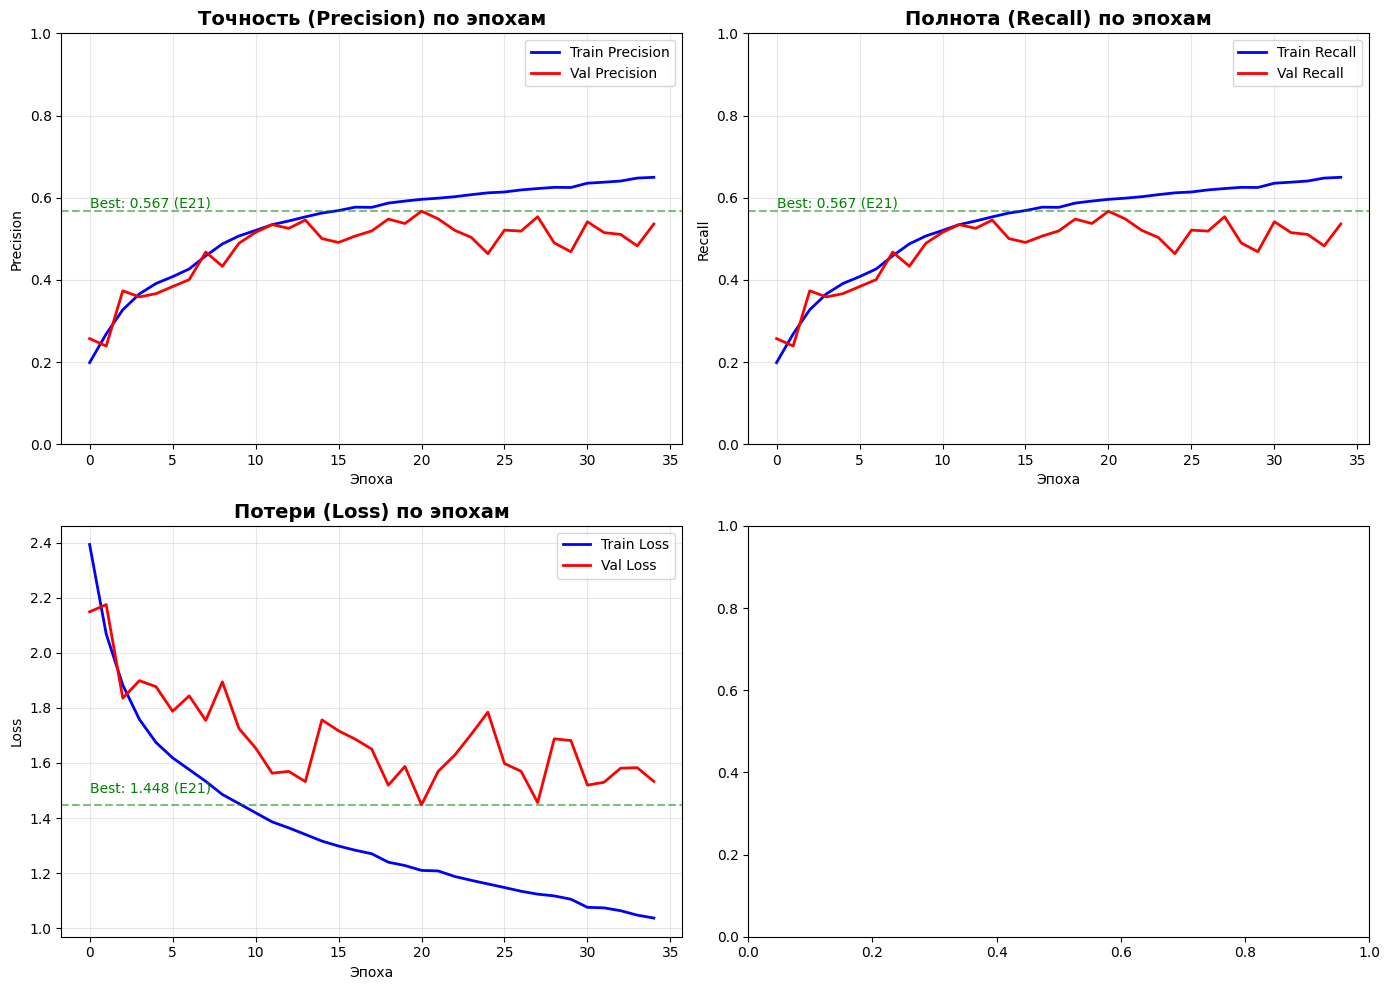

In [96]:
# После завершения обучения строим графики
import matplotlib.pyplot as plt
import numpy as np

# Создаем фигуру с 4 графиками
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Precision (Точность)
axes[0, 0].plot(train_precisions_model_parallel, 'b-', linewidth=2, label='Train Precision')
axes[0, 0].plot(val_precisions_model_parallel, 'r-', linewidth=2, label='Val Precision')
axes[0, 0].set_title('Точность (Precision) по эпохам', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

best_val_precision = max(val_precisions_model_parallel)
best_epoch_precision = val_precisions_model_parallel.index(best_val_precision) + 1
axes[0, 0].axhline(y=best_val_precision, color='g', linestyle='--', alpha=0.5)
axes[0, 0].text(0, best_val_precision + 0.01, f'Best: {best_val_precision:.3f} (E{best_epoch_precision})',
                fontsize=10, color='green')

# График 2: Recall (Полнота)
axes[0, 1].plot(train_recalls_model_parallel, 'b-', linewidth=2, label='Train Recall')
axes[0, 1].plot(val_recalls_model_parallel, 'r-', linewidth=2, label='Val Recall')
axes[0, 1].set_title('Полнота (Recall) по эпохам', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

best_val_recall = max(val_recalls_model_parallel)
best_epoch_recall = val_recalls_model_parallel.index(best_val_recall) + 1
axes[0, 1].axhline(y=best_val_recall, color='g', linestyle='--', alpha=0.5)
axes[0, 1].text(0, best_val_recall + 0.01, f'Best: {best_val_recall:.3f} (E{best_epoch_recall})',
                fontsize=10, color='green')

# График 3: Loss (Потери)
axes[1, 0].plot(train_lossess_model_parallel, 'b-', linewidth=2, label='Train Loss')
axes[1, 0].plot(val_lossess_model_parallel, 'r-', linewidth=2, label='Val Loss')
axes[1, 0].set_title('Потери (Loss) по эпохам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Добавляем аннотацию с лучшим loss
best_val_loss = min(val_lossess_model_parallel)
best_epoch_loss = val_lossess_model_parallel.index(best_val_loss) + 1
axes[1, 0].axhline(y=best_val_loss, color='g', linestyle='--', alpha=0.5)
axes[1, 0].text(0, best_val_loss + max(val_lossess_model_parallel)*0.02,
                f'Best: {best_val_loss:.3f} (E{best_epoch_loss})',
                fontsize=10, color='green')


plt.tight_layout()
plt.show()

In [81]:
class MinimalTextCNN(nn.Module):
    def __init__(self, vocab_size, output_dim, emb_dim=100, max_len=200):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.emb_dropout = nn.Dropout(0.3)

        # ПАРАЛЛЕЛЬНЫЙ БЛОК 1:
        self.parallel1 = nn.Sequential(
            nn.Conv1d(emb_dim, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2, stride=2)
        )

        # ПАРАЛЛЕЛЬНЫЙ БЛОК 2:
        self.parallel2 = nn.Sequential(
            nn.Conv1d(emb_dim, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AvgPool1d(2, stride=2)
        )

        self.conv1 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool = nn.MaxPool1d(2, stride=2)
        self.dropout2 = nn.Dropout(0.4)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.5)

        #  FC слои
        self.fc1 = nn.Linear(256, 128)
        self.fc_dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 64)
        self.fc_dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, output_dim)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Embedding
        x = self.embedding(x)  # (batch, seq_len, emb_dim)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)  # (batch, emb_dim, seq_len)

        # Параллельные блоки
        p1 = self.parallel1(x)
        p2 = self.parallel2(x)

        # Объединение
        x = torch.cat([p1, p2], dim=1)  # (batch, 64, seq_len/2)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout2(x)

        x = self.global_pool(x)
        x = self.dropout3(x)

        x = x.squeeze(-1)  # (batch, 256)

        # FC слои
        x = F.relu(self.fc1(x))
        x = self.fc_dropout1(x)

        x = F.relu(self.fc2(x))
        x = self.fc_dropout2(x)

        x = self.fc3(x)
        x = self.softmax(x)

        return x


Количество слоев: 21
Параметры модели: 2,601,411

Распределение по типам слоев:
  AdaptiveAvgPool1d: 1
  AvgPool1d: 1
  BatchNorm1d: 4
  Conv1d: 4
  Dropout: 6
  Linear: 3
  MaxPool1d: 2


In [97]:
model_minimal = MinimalTextCNN(
    vocab_size=len(word2id),
    output_dim=len(label2id),
    emb_dim=100,
    max_len=MAX_LEN
).to(device)

def count_layers(model):
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear, nn.Dropout,
                              nn.MaxPool1d, nn.AvgPool1d, nn.AdaptiveAvgPool1d,
                              nn.BatchNorm1d)):
            layers.append((name, type(module).__name__))
    return layers

layers = count_layers(model_minimal)
layer_count = len(layers)

print(f"Количество слоев: {layer_count}")
print(f"Параметры модели: {sum(p.numel() for p in model_minimal.parameters()):,}")

print("\nРаспределение по типам слоев:")
layer_types = {}
for _, layer_type in layers:
    layer_types[layer_type] = layer_types.get(layer_type, 0) + 1

for layer_type, count in sorted(layer_types.items()):
    print(f"  {layer_type}: {count}")

Количество слоев: 21
Параметры модели: 2,601,411

Распределение по типам слоев:
  AdaptiveAvgPool1d: 1
  AvgPool1d: 1
  BatchNorm1d: 4
  Conv1d: 4
  Dropout: 6
  Linear: 3
  MaxPool1d: 2


In [98]:
optimizer = optim.AdamW(model_minimal.parameters(), lr=0.001)
criterion = nn.NLLLoss()

epochs = 35
print(f"\nОбучение модели...")

train_losses_model_minimal = []
train_precisions_model_minimal = []
train_recalls_model_minimal = []
val_losses_model_minimal = []
val_precisions_model_minimal = []
val_recalls_model_minimal = []

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Эпоха {epoch+1}/{epochs}")
    print(f"{'='*50}")

    # Обучение
    train_loss, train_precision, train_recall = train(model_minimal, training_generator, optimizer, criterion)

    # Валидация
    val_loss, val_precision, val_recall = evaluate(model_minimal, valid_generator, criterion)

    # Сохранение метрик
    train_losses_model_minimal.append(train_loss)
    train_precisions_model_minimal.append(train_precision)
    train_recalls_model_minimal.append(train_recall)
    val_losses_model_minimal.append(val_loss)
    val_precisions_model_minimal.append(val_precision)
    val_recalls_model_minimal.append(val_recall)

    print(f"Train: Loss={train_loss:.4f}, Precision={train_precision:.4f}, Recall={train_recall:.4f}")
    print(f"Val:   Loss={val_loss:.4f}, Precision={val_precision:.4f}, Recall={val_recall:.4f}")


Обучение модели...

Эпоха 1/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=2.2609, Precision=0.2220, Recall=0.2220
Val:   Loss=2.4622, Precision=0.1861, Recall=0.1861

Эпоха 2/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.4245, Precision=0.8612, Recall=0.8612
Val:   Loss=1.1208, Precision=0.7030, Recall=0.7030

Эпоха 35/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.4222, Precision=0.8631, Recall=0.8631
Val:   Loss=1.0880, Precision=0.7023, Recall=0.7023


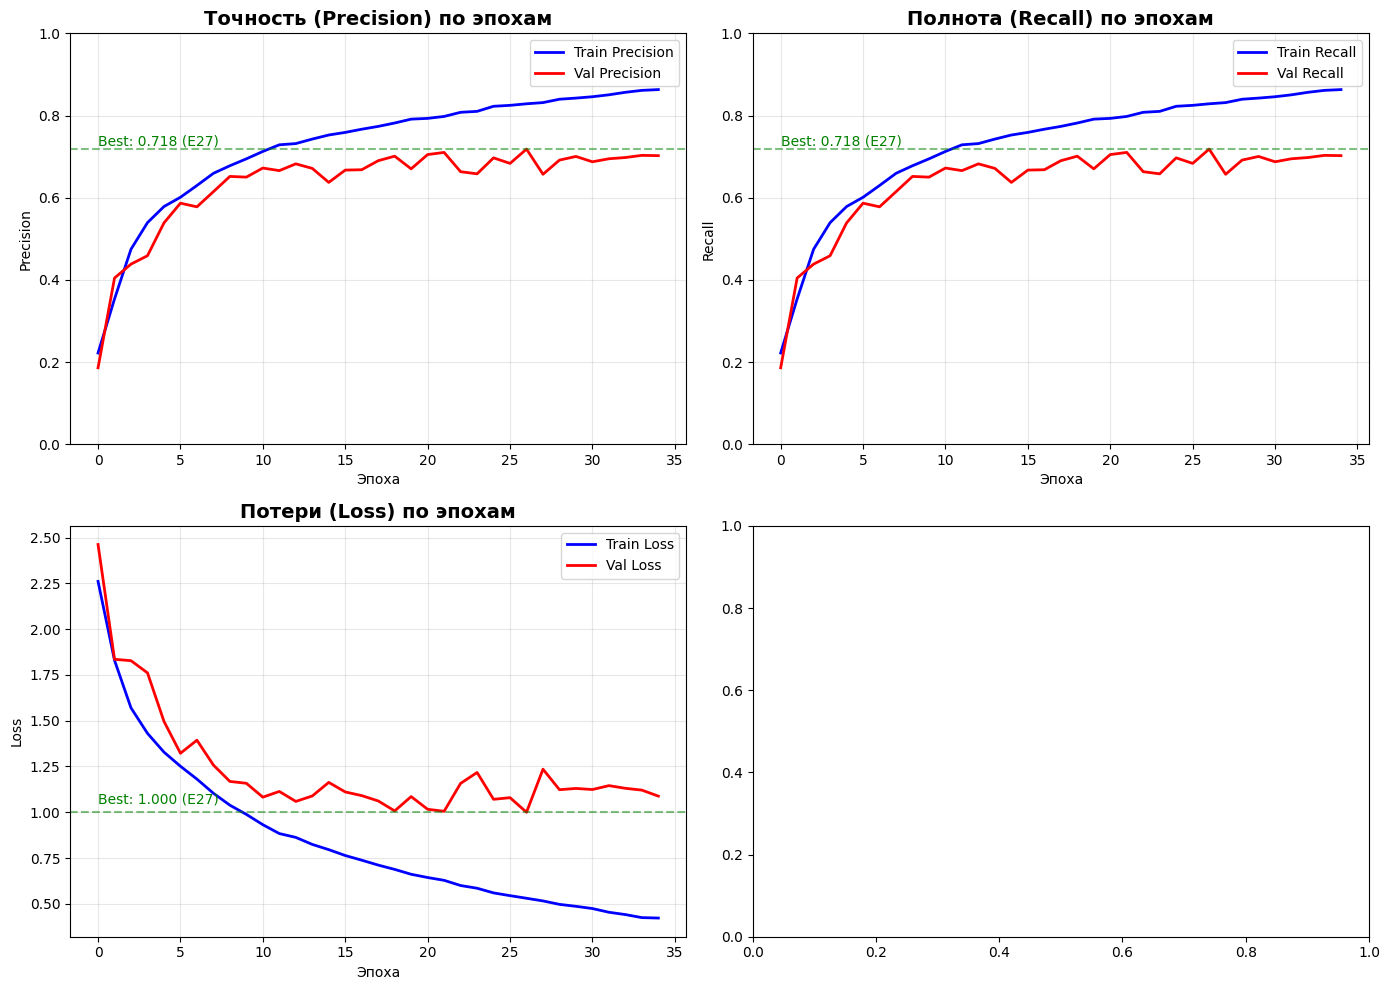

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Precision (Точность)
axes[0, 0].plot(train_precisions_model_minimal, 'b-', linewidth=2, label='Train Precision')
axes[0, 0].plot(val_precisions_model_minimal, 'r-', linewidth=2, label='Val Precision')
axes[0, 0].set_title('Точность (Precision) по эпохам', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

best_val_precision = max(val_precisions_model_minimal)
best_epoch_precision = val_precisions_model_minimal.index(best_val_precision) + 1
axes[0, 0].axhline(y=best_val_precision, color='g', linestyle='--', alpha=0.5)
axes[0, 0].text(0, best_val_precision + 0.01, f'Best: {best_val_precision:.3f} (E{best_epoch_precision})',
                fontsize=10, color='green')

# График 2: Recall (Полнота)
axes[0, 1].plot(train_recalls_model_minimal, 'b-', linewidth=2, label='Train Recall')
axes[0, 1].plot(val_recalls_model_minimal, 'r-', linewidth=2, label='Val Recall')
axes[0, 1].set_title('Полнота (Recall) по эпохам', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

best_val_recall = max(val_recalls_model_minimal)
best_epoch_recall = val_recalls_model_minimal.index(best_val_recall) + 1
axes[0, 1].axhline(y=best_val_recall, color='g', linestyle='--', alpha=0.5)
axes[0, 1].text(0, best_val_recall + 0.01, f'Best: {best_val_recall:.3f} (E{best_epoch_recall})',
                fontsize=10, color='green')

# График 3: Loss (Потери)
axes[1, 0].plot(train_losses_model_minimal, 'b-', linewidth=2, label='Train Loss')
axes[1, 0].plot(val_losses_model_minimal, 'r-', linewidth=2, label='Val Loss')
axes[1, 0].set_title('Потери (Loss) по эпохам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

best_val_loss = min(val_losses_model_minimal)
best_epoch_loss = val_losses_model_minimal.index(best_val_loss) + 1
axes[1, 0].axhline(y=best_val_loss, color='g', linestyle='--', alpha=0.5)
axes[1, 0].text(0, best_val_loss + max(val_losses_model_minimal)*0.02,
                f'Best: {best_val_loss:.3f} (E{best_epoch_loss})',
                fontsize=10, color='green')


plt.tight_layout()
plt.show()

In [100]:
class ComplicatedTextCNN(nn.Module):
    def __init__(self, vocab_size, output_dim, emb_dim=128, max_len=200):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.emb_dropout = nn.Dropout(0.3)


        # ПАРАЛЛЕЛЬНЫЙ БЛОК 1:
        self.parallel1 = nn.Sequential(
            nn.Conv1d(emb_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.parallel2 = nn.Sequential(
            nn.Conv1d(emb_dim, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=2, stride=2)
        )


        self.conv1 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(0.4)

        self.conv3 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(512)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout3 = nn.Dropout(0.5)

        # FC слои

        self.fc1 = nn.Linear(512, 256)
        self.fc_bn1 = nn.BatchNorm1d(256)
        self.fc_dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(256, 128)
        self.fc_dropout2 = nn.Dropout(0.4)

        self.fc3 = nn.Linear(128, 64)
        self.fc_dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(64, output_dim)

        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Embedding
        x = self.embedding(x)  # (batch, seq_len, emb_dim)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)  # (batch, emb_dim, seq_len)

        # Параллельные блоки
        p1 = self.parallel1(x)
        p2 = self.parallel2(x)

        # Объединение
        x = torch.cat([p1, p2], dim=1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x)
        x = self.dropout3(x)

        x = x.squeeze(-1)

        # FC слои
        x = F.relu(self.fc_bn1(self.fc1(x)))
        x = self.fc_dropout1(x)

        x = F.relu(self.fc2(x))
        x = self.fc_dropout2(x)

        x = F.relu(self.fc3(x))
        x = self.fc_dropout3(x)

        x = self.fc4(x)
        x = self.softmax(x)

        return x



In [101]:
model_complicated = ComplicatedTextCNN(
    vocab_size=len(word2id),
    output_dim=len(label2id),
    emb_dim=128,
    max_len=MAX_LEN
).to(device)

def count_layers(model):
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear, nn.Dropout,
                              nn.MaxPool1d, nn.AvgPool1d, nn.AdaptiveAvgPool1d,
                              nn.BatchNorm1d)):
            layers.append((name, type(module).__name__))
    return layers

layers = count_layers(model_complicated)
print(f"Общее количество слоев: {len(layers)}")
print(f"Параметры модели: {sum(p.numel() for p in model_complicated.parameters()):,}")

print("\nТипы слоев:")
layer_types = {}
for _, layer_type in layers:
    layer_types[layer_type] = layer_types.get(layer_type, 0) + 1

for layer_type, count in layer_types.items():
    print(f"  {layer_type}: {count}")

Общее количество слоев: 26
Параметры модели: 3,867,283

Типы слоев:
  Dropout: 7
  Conv1d: 5
  BatchNorm1d: 6
  MaxPool1d: 2
  AvgPool1d: 1
  AdaptiveAvgPool1d: 1
  Linear: 4


In [102]:
optimizer = optim.AdamW(model_complicated.parameters(), lr=0.001)
criterion = nn.NLLLoss()

epochs = 35
print(f"\nОбучение модели...")

train_losses_model_complicated = []
train_precisions_model_complicated = []
train_recalls_model_complicated = []
val_losses_model_complicated = []
val_precisions_model_complicated = []
val_recalls_model_complicated = []

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Эпоха {epoch+1}/{epochs}")
    print(f"{'='*50}")

    # Обучение (используем вашу функцию)
    train_loss, train_precision, train_recall = train(model_complicated, training_generator, optimizer, criterion)

    # Валидация (используем вашу функцию)
    val_loss, val_precision, val_recall = evaluate(model_complicated, valid_generator, criterion)

    # Сохранение метрик
    train_losses_model_complicated.append(train_loss)
    train_precisions_model_complicated.append(train_precision)
    train_recalls_model_complicated.append(train_recall)
    val_losses_model_complicated.append(val_loss)
    val_precisions_model_complicated.append(val_precision)
    val_recalls_model_complicated.append(val_recall)

    print(f"Train: Loss={train_loss:.4f}, Precision={train_precision:.4f}, Recall={train_recall:.4f}")
    print(f"Val:   Loss={val_loss:.4f}, Precision={val_precision:.4f}, Recall={val_recall:.4f}")


Обучение модели...

Эпоха 1/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=2.1945, Precision=0.2571, Recall=0.2571
Val:   Loss=2.2810, Precision=0.2647, Recall=0.2647

Эпоха 2/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.3212, Precision=0.8991, Recall=0.8991
Val:   Loss=1.2758, Precision=0.6900, Recall=0.6900

Эпоха 35/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.3162, Precision=0.9025, Recall=0.9025
Val:   Loss=1.2612, Precision=0.7191, Recall=0.7191


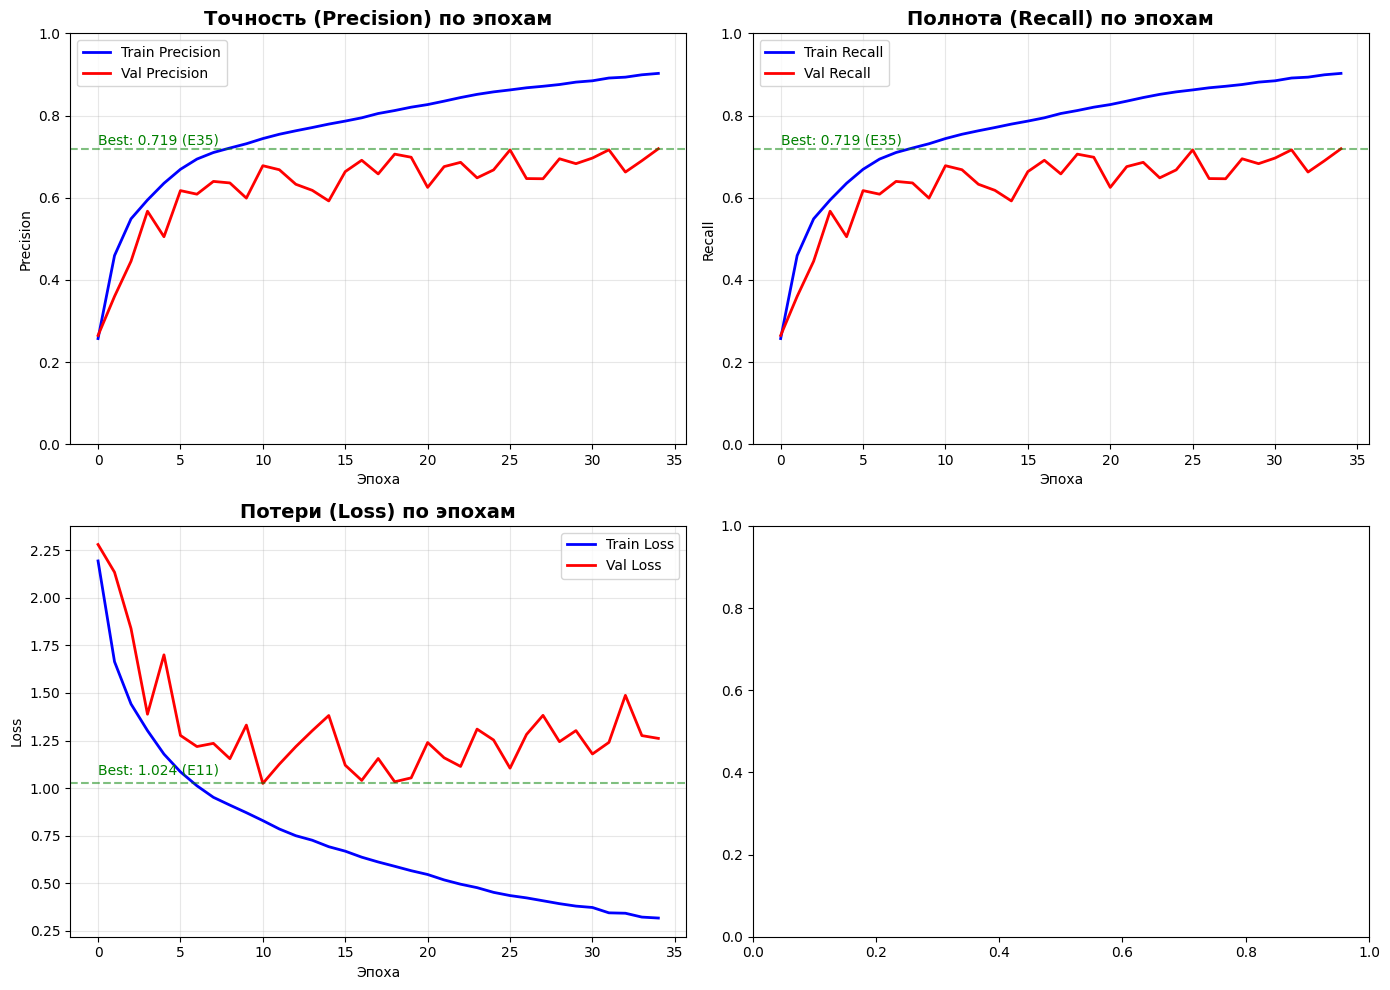

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Precision (Точность)
axes[0, 0].plot(train_precisions_model_complicated, 'b-', linewidth=2, label='Train Precision')
axes[0, 0].plot(val_precisions_model_complicated, 'r-', linewidth=2, label='Val Precision')
axes[0, 0].set_title('Точность (Precision) по эпохам', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

best_val_precision = max(val_precisions_model_complicated)
best_epoch_precision = val_precisions_model_complicated.index(best_val_precision) + 1
axes[0, 0].axhline(y=best_val_precision, color='g', linestyle='--', alpha=0.5)
axes[0, 0].text(0, best_val_precision + 0.01, f'Best: {best_val_precision:.3f} (E{best_epoch_precision})',
                fontsize=10, color='green')

# График 2: Recall (Полнота)
axes[0, 1].plot(train_recalls_model_complicated, 'b-', linewidth=2, label='Train Recall')
axes[0, 1].plot(val_recalls_model_complicated, 'r-', linewidth=2, label='Val Recall')
axes[0, 1].set_title('Полнота (Recall) по эпохам', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

best_val_recall = max(val_recalls_model_complicated)
best_epoch_recall = val_recalls_model_complicated.index(best_val_recall) + 1
axes[0, 1].axhline(y=best_val_recall, color='g', linestyle='--', alpha=0.5)
axes[0, 1].text(0, best_val_recall + 0.01, f'Best: {best_val_recall:.3f} (E{best_epoch_recall})',
                fontsize=10, color='green')

# График 3: Loss (Потери)
axes[1, 0].plot(train_losses_model_complicated, 'b-', linewidth=2, label='Train Loss')
axes[1, 0].plot(val_losses_model_complicated, 'r-', linewidth=2, label='Val Loss')
axes[1, 0].set_title('Потери (Loss) по эпохам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

best_val_loss = min(val_losses_model_complicated)
best_epoch_loss = val_losses_model_complicated.index(best_val_loss) + 1
axes[1, 0].axhline(y=best_val_loss, color='g', linestyle='--', alpha=0.5)
axes[1, 0].text(0, best_val_loss + max(val_losses_model_complicated)*0.02,
                f'Best: {best_val_loss:.3f} (E{best_epoch_loss})',
                fontsize=10, color='green')


plt.tight_layout()
plt.show()

In [105]:
class OptimizedComplexCNN(nn.Module):
    def __init__(self, vocab_size, output_dim, emb_dim=128, max_len=200):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.emb_dropout = nn.Dropout(0.4)

        # ПАРАЛЛЕЛЬНЫЙ БЛОК 1:
        self.parallel1 = nn.Sequential(
            nn.Conv1d(emb_dim, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # ПАРАЛЛЕЛЬНЫЙ БЛОК 2:
        self.parallel2 = nn.Sequential(
            nn.Conv1d(emb_dim, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=2, stride=2)
        )

        self.merge_conv = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.merge_bn = nn.BatchNorm1d(256)
        self.merge_dropout = nn.Dropout(0.4)

        self.conv1 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.4)

        self.conv2 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(512)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout2 = nn.Dropout(0.5)

        # FC слои

        self.fc1 = nn.Linear(512, 256)
        self.fc_bn1 = nn.BatchNorm1d(256)
        self.fc_dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(256, 128)
        self.fc_bn2 = nn.BatchNorm1d(128)
        self.fc_dropout2 = nn.Dropout(0.4)

        self.fc3 = nn.Linear(128, 64)
        self.fc_dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(64, output_dim)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # Embedding
        x = self.embedding(x)  # (batch, seq_len, emb_dim)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)  # (batch, emb_dim, seq_len)

        # Параллельные блоки
        p1 = self.parallel1(x)
        p2 = self.parallel2(x)

        # Объединение
        x = torch.cat([p1, p2], dim=1)

        x = F.relu(self.merge_bn(self.merge_conv(x)))
        x = self.merge_dropout(x)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.global_pool(x)
        x = self.dropout2(x)

        x = x.squeeze(-1)

        # FC слои
        x = F.relu(self.fc_bn1(self.fc1(x)))
        x = self.fc_dropout1(x)

        x = F.relu(self.fc_bn2(self.fc2(x)))
        x = self.fc_dropout2(x)

        x = F.relu(self.fc3(x))
        x = self.fc_dropout3(x)

        x = self.fc4(x)
        x = self.softmax(x)

        return x

In [109]:
model_opt = OptimizedComplexCNN(
    vocab_size=len(word2id),
    output_dim=len(label2id),
    emb_dim=128,
    max_len=MAX_LEN
).to(device)


def count_layers(model):
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear, nn.Dropout,
                              nn.MaxPool1d, nn.AvgPool1d, nn.AdaptiveAvgPool1d,
                              nn.BatchNorm1d)):
            layers.append((name, type(module).__name__))
    return layers

layers = count_layers(model_opt)
print(f"Общее количество слоев: {len(layers)}")
print(f"Параметры модели: {sum(p.numel() for p in model_opt.parameters()):,}")

print("\nТипы слоев:")
layer_types = {}
for _, layer_type in layers:
    layer_types[layer_type] = layer_types.get(layer_type, 0) + 1

for layer_type, count in layer_types.items():
    print(f"  {layer_type}: {count}")

Общее количество слоев: 32
Параметры модели: 4,030,003

Типы слоев:
  Dropout: 8
  Conv1d: 7
  BatchNorm1d: 9
  MaxPool1d: 2
  AvgPool1d: 1
  AdaptiveAvgPool1d: 1
  Linear: 4


In [110]:
optimizer = optim.Adam(model_opt.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.NLLLoss()

epochs = 35
print("\nОбучение финальной модели...")

train_losses_model_opt = []
train_precisions_model_opt = []
train_recalls_model_opt = []
val_losses_model_opt = []
val_precisions_model_opt = []
val_recalls_model_opt = []

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Эпоха {epoch+1}/{epochs}")
    print(f"{'='*50}")

    # Обучение (используем вашу функцию)
    train_loss, train_precision, train_recall = train(model_opt, training_generator, optimizer, criterion)

    # Валидация (используем вашу функцию)
    val_loss, val_precision, val_recall = evaluate(model_opt, valid_generator, criterion)

    # Сохранение метрик
    train_losses_model_opt.append(train_loss)
    train_precisions_model_opt.append(train_precision)
    train_recalls_model_opt.append(train_recall)
    val_losses_model_opt.append(val_loss)
    val_precisions_model_opt.append(val_precision)
    val_recalls_model_opt.append(val_recall)

    print(f"Train: Loss={train_loss:.4f}, Precision={train_precision:.4f}, Recall={train_recall:.4f}")
    print(f"Val:   Loss={val_loss:.4f}, Precision={val_precision:.4f}, Recall={val_recall:.4f}")


Обучение финальной модели...

Эпоха 1/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=2.4876, Precision=0.1885, Recall=0.1885
Val:   Loss=3.0376, Precision=0.0727, Recall=0.0727

Эпоха 2/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.4003, Precision=0.8781, Recall=0.8781
Val:   Loss=1.5030, Precision=0.7150, Recall=0.7150

Эпоха 35/35


Training:   0%|          | 0/165 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]

Train: Loss=0.3791, Precision=0.8829, Recall=0.8829
Val:   Loss=1.4691, Precision=0.7225, Recall=0.7225


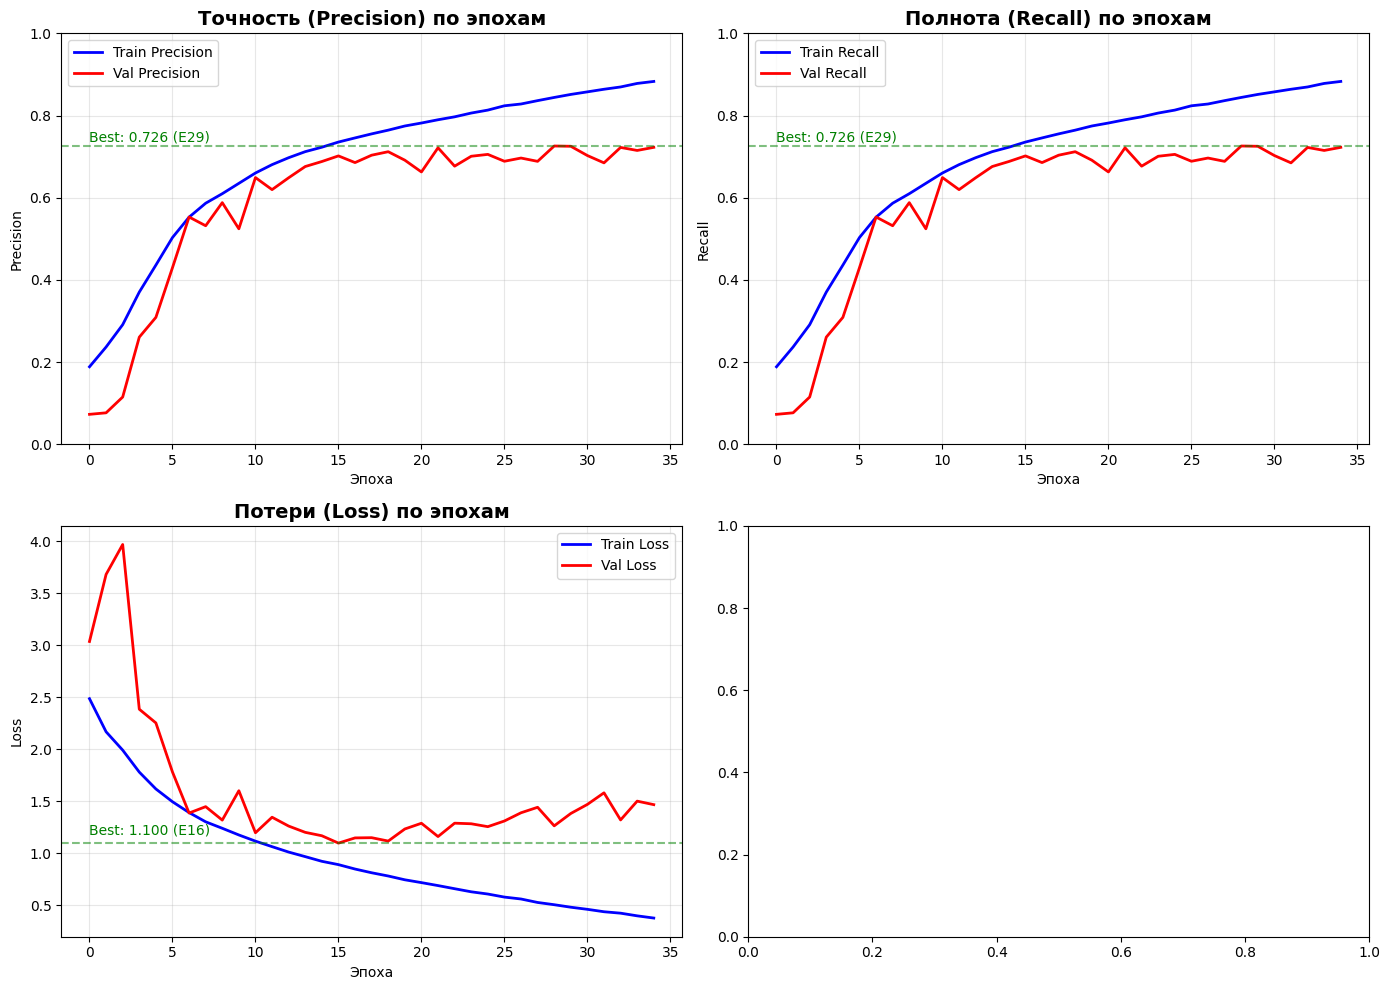

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Precision (Точность)
axes[0, 0].plot(train_precisions_model_opt, 'b-', linewidth=2, label='Train Precision')
axes[0, 0].plot(val_precisions_model_opt, 'r-', linewidth=2, label='Val Precision')
axes[0, 0].set_title('Точность (Precision) по эпохам', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

best_val_precision = max(val_precisions_model_opt)
best_epoch_precision = val_precisions_model_opt.index(best_val_precision) + 1
axes[0, 0].axhline(y=best_val_precision, color='g', linestyle='--', alpha=0.5)
axes[0, 0].text(0, best_val_precision + 0.01, f'Best: {best_val_precision:.3f} (E{best_epoch_precision})',
                fontsize=10, color='green')

# График 2: Recall (Полнота)
axes[0, 1].plot(train_recalls_model_opt, 'b-', linewidth=2, label='Train Recall')
axes[0, 1].plot(val_recalls_model_opt, 'r-', linewidth=2, label='Val Recall')
axes[0, 1].set_title('Полнота (Recall) по эпохам', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])

best_val_recall = max(val_recalls_model_opt)
best_epoch_recall = val_recalls_model_opt.index(best_val_recall) + 1
axes[0, 1].axhline(y=best_val_recall, color='g', linestyle='--', alpha=0.5)
axes[0, 1].text(0, best_val_recall + 0.01, f'Best: {best_val_recall:.3f} (E{best_epoch_recall})',
                fontsize=10, color='green')

# График 3: Loss (Потери)
axes[1, 0].plot(train_losses_model_opt, 'b-', linewidth=2, label='Train Loss')
axes[1, 0].plot(val_losses_model_opt, 'r-', linewidth=2, label='Val Loss')
axes[1, 0].set_title('Потери (Loss) по эпохам', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

best_val_loss = min(val_losses_model_opt)
best_epoch_loss = val_losses_model_opt.index(best_val_loss) + 1
axes[1, 0].axhline(y=best_val_loss, color='g', linestyle='--', alpha=0.5)
axes[1, 0].text(0, best_val_loss + max(val_losses_model_opt)*0.02,
                f'Best: {best_val_loss:.3f} (E{best_epoch_loss})',
                fontsize=10, color='green')


plt.tight_layout()
plt.show()

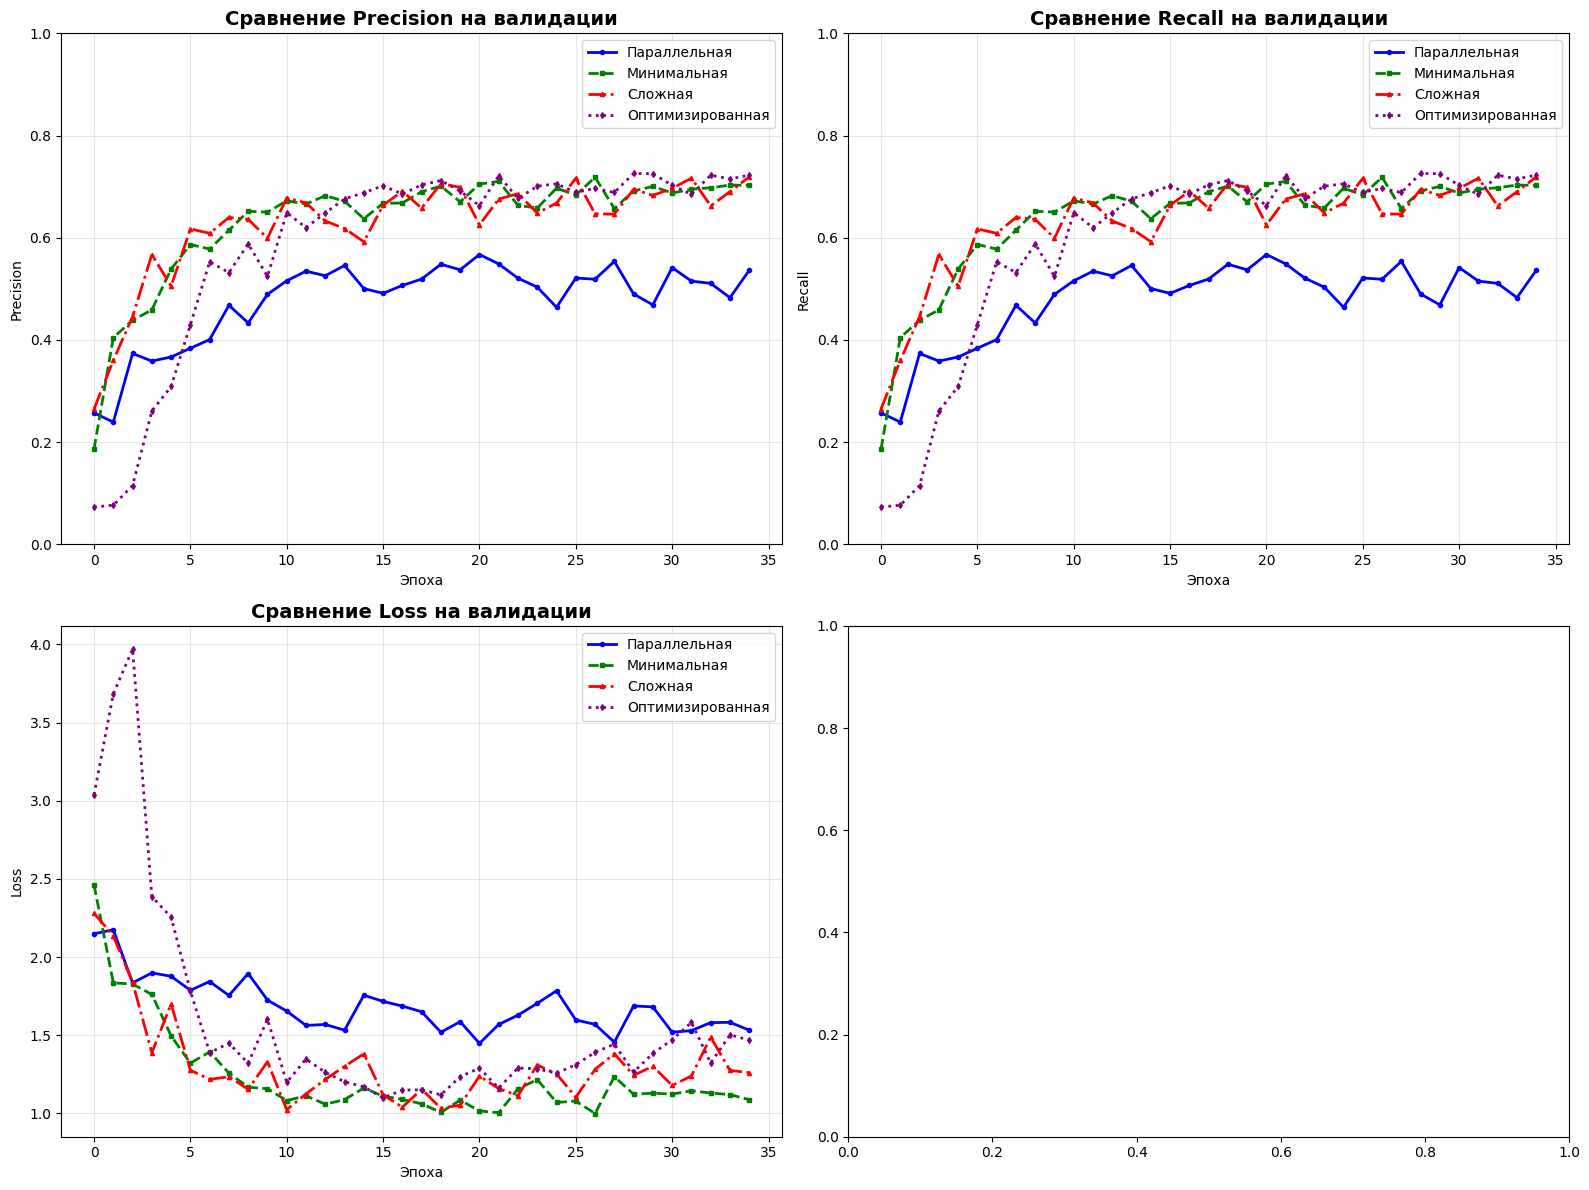

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем фигуру с 4 графиками
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Настройки стилей для разных моделей
model_styles = {
    'parallel': {'color': 'blue', 'linestyle': '-', 'linewidth': 2, 'marker': 'o', 'markersize': 3, 'label': 'Параллельная'},
    'minimal': {'color': 'green', 'linestyle': '--', 'linewidth': 2, 'marker': 's', 'markersize': 3, 'label': 'Минимальная'},
    'complicated': {'color': 'red', 'linestyle': '-.', 'linewidth': 2, 'marker': '^', 'markersize': 3, 'label': 'Сложная'},
    'opt': {'color': 'purple', 'linestyle': ':', 'linewidth': 2, 'marker': 'd', 'markersize': 3, 'label': 'Оптимизированная'}
}

# График 1: Сравнение Precision всех моделей
axes[0, 0].plot(val_precisions_model_parallel, **model_styles['parallel'])
axes[0, 0].plot(val_precisions_model_minimal, **model_styles['minimal'])
axes[0, 0].plot(val_precisions_model_complicated, **model_styles['complicated'])
axes[0, 0].plot(val_precisions_model_opt, **model_styles['opt'])

axes[0, 0].set_title('Сравнение Precision на валидации', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='best')
axes[0, 0].set_ylim([0, 1])


# График 2: Сравнение Recall всех моделей
axes[0, 1].plot(val_recalls_model_parallel, **model_styles['parallel'])
axes[0, 1].plot(val_recalls_model_minimal, **model_styles['minimal'])
axes[0, 1].plot(val_recalls_model_complicated, **model_styles['complicated'])
axes[0, 1].plot(val_recalls_model_opt, **model_styles['opt'])

axes[0, 1].set_title('Сравнение Recall на валидации', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='best')
axes[0, 1].set_ylim([0, 1])

# График 3: Сравнение Loss всех моделей
axes[1, 0].plot(val_lossess_model_parallel, **model_styles['parallel'])
axes[1, 0].plot(val_losses_model_minimal, **model_styles['minimal'])
axes[1, 0].plot(val_losses_model_complicated, **model_styles['complicated'])
axes[1, 0].plot(val_losses_model_opt, **model_styles['opt'])

axes[1, 0].set_title('Сравнение Loss на валидации', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='best')

plt.tight_layout()
plt.show()

In [115]:
def predict_single_text(model, text, word2id, label2id, max_len=200, device='cpu'):
    """
    Предсказывает класс для одного текста
    """
    # Предобработка текста
    tokens = text.lower().split()
    tokens = [token.strip(punctuation) for token in tokens if token.strip(punctuation)]
    tokens = [word2id.get(token, 0) for token in tokens[:max_len]]

    # Паддинг
    if len(tokens) < max_len:
        tokens = tokens + [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]

    # Преобразование в тензор
    input_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)

    # Предсказание
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.exp(output)
        confidence, predicted_idx = torch.max(probabilities, 1)

    # Преобразование индекса в метку
    id2label = {v: k for k, v in label2id.items()}
    predicted_label = id2label[predicted_idx.item()]

    # Топ-3 вероятных класса
    all_probs = probabilities.squeeze().cpu().numpy()
    prob_dict = {id2label[i]: float(all_probs[i]) for i in range(len(all_probs))}
    sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:3]

    return predicted_label, confidence.item(), sorted_probs

In [116]:

test_texts = [
    "Российские футболисты одержали победу в матче чемпионата мира.",
    "Экономика России показывает рост, несмотря на санкции.",
    "Новая выставка современного искусства открылась в Москве.",
    "Компания Apple представила новый iPhone с улучшенной камерой.",
    "Президент провел встречу с лидерами европейских стран."
]

print("\nТестирование финальной модели на новых текстах:")
print("="*70)

for i, text in enumerate(test_texts, 1):
    predicted_label, confidence, top3 = predict_single_text(
        model_opt, text, word2id, label2id, MAX_LEN, device
    )

    print(f"\nТекст {i}: {text[:80]}...")
    print(f"  Предсказанный класс: {predicted_label}")
    print(f"  Уверенность: {confidence:.4f}")
    print(f"  Топ-3 варианта:")
    for label, prob in top3:
        print(f"    - {label}: {prob:.4f}")


Тестирование финальной модели на новых текстах:

Текст 1: Российские футболисты одержали победу в матче чемпионата мира....
  Предсказанный класс: Спорт
  Уверенность: 0.9988
  Топ-3 варианта:
    - Спорт: 0.9988
    - Из жизни: 0.0006
    - Путешествия: 0.0004

Текст 2: Экономика России показывает рост, несмотря на санкции....
  Предсказанный класс: Экономика
  Уверенность: 0.4698
  Топ-3 варианта:
    - Экономика: 0.4698
    - Путешествия: 0.1496
    - Интернет и СМИ: 0.1139

Текст 3: Новая выставка современного искусства открылась в Москве....
  Предсказанный класс: Культура
  Уверенность: 0.9534
  Топ-3 варианта:
    - Культура: 0.9534
    - Культпросвет : 0.0204
    - Из жизни: 0.0102

Текст 4: Компания Apple представила новый iPhone с улучшенной камерой....
  Предсказанный класс: Наука и техника
  Уверенность: 0.7715
  Топ-3 варианта:
    - Наука и техника: 0.7715
    - Интернет и СМИ: 0.1611
    - Мир: 0.0233

Текст 5: Президент провел встречу с лидерами европейских стран....
 